In [41]:
from google.colab import drive
import os
import glob

# Mount Google Drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [42]:

# Path to your dataset directory
dataset_dir = '/content/drive/MyDrive/projecto de grad/archive'

# List all CSV files in the directory
csv_files = glob.glob(os.path.join(dataset_dir, '*.csv'))

# Print all CSV files found
if csv_files:
    print("Found the following CSV files:")
    for file in csv_files:
        print(file)
else:
    print("No CSV files found in the specified directory!")


Found the following CSV files:
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-1-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-3-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-34-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-20-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-21-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-35-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-44-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-42-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-48-1conn.log.labeled.csv
/content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-60-1conn.log.labeled.csv
/

In [43]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, Flatten, MaxPooling1D, LSTM, Reshape, Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [44]:


# Step 1: Load the Dataset
print("Available CSV files in your dataset directory:")
for i, file in enumerate(csv_files):
    print(f"{i + 1}. {file}")

# Select the dataset to use
file_index = 0  # Use the first CSV file for now


# Load the dataset with a specific delimiter
dataset_file = csv_files[file_index]
print("\nLoading dataset from:", dataset_file)
df = pd.read_csv(dataset_file, delimiter='|', low_memory=False, na_values=['?', 'NA', 'null', '-'])


Available CSV files in your dataset directory:
1. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-1-1conn.log.labeled.csv
2. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-3-1conn.log.labeled.csv
3. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-34-1conn.log.labeled.csv
4. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-20-1conn.log.labeled.csv
5. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-21-1conn.log.labeled.csv
6. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-35-1conn.log.labeled.csv
7. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-44-1conn.log.labeled.csv
8. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-42-1conn.log.labeled.csv
9. /content/drive/MyDrive/projecto de grad/archive/CTU-IoT-Malware-Capture-48-1conn.log.labeled.csv
10. /content/drive/MyDrive/projecto de grad/archive/CTU

In [45]:

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
             ts                 uid        id.orig_h  id.orig_p  \
0  1.525880e+09  CUmrqr4svHuSXJy5z7  192.168.100.103    51524.0   
1  1.525880e+09  CH98aB3s1kJeq6SFOc  192.168.100.103    56305.0   
2  1.525880e+09   C3GBTkINvXNjVGtN5  192.168.100.103    41101.0   
3  1.525880e+09   CDe43c1PtgynajGI6  192.168.100.103    60905.0   
4  1.525880e+09  CJaDcG3MZzvf1YVYI4  192.168.100.103    44301.0   

         id.resp_h  id.resp_p proto service  duration  orig_bytes  ...  \
0   65.127.233.163       23.0   tcp     NaN  2.999051         0.0  ...   
1    63.150.16.171       23.0   tcp     NaN       NaN         NaN  ...   
2     111.40.23.49       23.0   tcp     NaN       NaN         NaN  ...   
3  131.174.215.147       23.0   tcp     NaN  2.998796         0.0  ...   
4      91.42.47.63       23.0   tcp     NaN       NaN         NaN  ...   

   local_resp missed_bytes  history  orig_pkts  orig_ip_bytes resp_pkts  \
0         NaN          0.0        S        3.0  

In [46]:


# Basic dataset information
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008748 entries, 0 to 1008747
Data columns (total 23 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   ts              1008748 non-null  float64
 1   uid             1008748 non-null  object 
 2   id.orig_h       1008748 non-null  object 
 3   id.orig_p       1008748 non-null  float64
 4   id.resp_h       1008748 non-null  object 
 5   id.resp_p       1008748 non-null  float64
 6   proto           1008748 non-null  object 
 7   service         3241 non-null     object 
 8   duration        212448 non-null   float64
 9   orig_bytes      212448 non-null   float64
 10  resp_bytes      212448 non-null   float64
 11  conn_state      1008748 non-null  object 
 12  local_orig      0 non-null        float64
 13  local_resp      0 non-null        float64
 14  missed_bytes    1008748 non-null  float64
 15  history         991327 non-null   object 
 16  orig_pkts       10087

In [47]:

print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ts                      0
uid                     0
id.orig_h               0
id.orig_p               0
id.resp_h               0
id.resp_p               0
proto                   0
service           1005507
duration           796300
orig_bytes         796300
resp_bytes         796300
conn_state              0
local_orig        1008748
local_resp        1008748
missed_bytes            0
history             17421
orig_pkts               0
orig_ip_bytes           0
resp_pkts               0
resp_ip_bytes           0
tunnel_parents    1008748
label                   0
detailed-label     469275
dtype: int64


In [48]:

# Step 3: Clean Missing Values
# Drop columns with more than 50% missing values
missing_threshold = 0.2
total_rows = len(df)
columns_to_drop = [col for col in df.columns if df[col].isnull().sum() / total_rows > missing_threshold]
print("\nDropping columns with more than 50% missing values:", columns_to_drop)
df = df.drop(columns=columns_to_drop)


Dropping columns with more than 50% missing values: ['service', 'duration', 'orig_bytes', 'resp_bytes', 'local_orig', 'local_resp', 'tunnel_parents', 'detailed-label']


In [49]:
print(df.isnull().sum())

ts                   0
uid                  0
id.orig_h            0
id.orig_p            0
id.resp_h            0
id.resp_p            0
proto                0
conn_state           0
missed_bytes         0
history          17421
orig_pkts            0
orig_ip_bytes        0
resp_pkts            0
resp_ip_bytes        0
label                0
dtype: int64


In [50]:
# Drop rows where 'history' has missing values
if 'history' in df.columns:
    print("\nDropping rows with missing 'history' values")
    df = df.dropna(subset=['history'])


Dropping rows with missing 'history' values


In [51]:
# Count unique values for each column
unique_counts = df.nunique()

# Display columns with all unique or single unique values
print("Columns with all unique values:")
print(unique_counts[unique_counts == len(df)])  # Likely IDs or timestamps

print("\nColumns with a single unique value:")
print(unique_counts[unique_counts <= 1])  # Not useful

Columns with all unique values:
ts     991327
uid    991327
dtype: int64

Columns with a single unique value:
missed_bytes    1
dtype: int64


In [52]:
#No need for IPs or UID because of biased
#tunnel parents local resp and local_origen doesnt have anything
irrelevant_cols = ['uid', 'ts', 'id.orig_h', 'id.resp_h']
df.drop(columns=irrelevant_cols, inplace=True)


In [53]:
print(df.head())

   id.orig_p  id.resp_p proto conn_state  missed_bytes history  orig_pkts  \
0    51524.0       23.0   tcp         S0           0.0       S        3.0   
1    56305.0       23.0   tcp         S0           0.0       S        1.0   
2    41101.0       23.0   tcp         S0           0.0       S        1.0   
3    60905.0       23.0   tcp         S0           0.0       S        3.0   
4    44301.0       23.0   tcp         S0           0.0       S        1.0   

   orig_ip_bytes  resp_pkts  resp_ip_bytes      label  
0          180.0        0.0            0.0  Malicious  
1           60.0        0.0            0.0  Malicious  
2           60.0        0.0            0.0  Malicious  
3          180.0        0.0            0.0  Malicious  
4           60.0        0.0            0.0  Malicious  


In [54]:

# Step 4: Encode Categorical Features
label_encoder = LabelEncoder()
for column in df.select_dtypes(include=['object']).columns:
    if column != 'label':  # Skip encoding the target column for now
        df[column] = label_encoder.fit_transform(df[column])

# Encode the target column 'label' into 0 (Benign) and 1 (Malicious)
if 'label' not in df.columns:
    raise ValueError("Target column 'label' not found in the dataset! Check column names.")

df['label'] = df['label'].apply(lambda x: 1 if x == 'Malicious' else 0)


In [55]:

# Step 5: Feature-Target Split
target_column = 'label'
features = df.drop(columns=[target_column])
labels = df[target_column]

print("\nFeature and Target Shapes:")
print(f"Features: {features.shape}, Labels: {labels.shape}")



Feature and Target Shapes:
Features: (991327, 10), Labels: (991327,)


In [56]:

# Step 6: Data Normalization
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

In [57]:

# Step 7: Split into Train/Validation/Test
X_train, X_temp, y_train, y_temp = train_test_split(features_scaled, labels, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("\nFinal Data Shapes:")
print(f"Training Features: {X_train.shape}, Training Labels: {y_train.shape}")
print(f"Validation Features: {X_val.shape}, Validation Labels: {y_val.shape}")
print(f"Testing Features: {X_test.shape}, Testing Labels: {y_test.shape}")



Final Data Shapes:
Training Features: (693928, 10), Training Labels: (693928,)
Validation Features: (148699, 10), Validation Labels: (148699,)
Testing Features: (148700, 10), Testing Labels: (148700,)


In [58]:
# Step 8: Reshape Data for CNN, LSTM, and Transformer Input
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val_cnn = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [59]:
# Step 9: Build and Train ANN Model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

ann_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
print("\nTraining the ANN model...")
history_ann = ann_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])



Training the ANN model...
Epoch 1/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 48s 2ms/step - accuracy: 0.9898 - loss: 0.0493 - val_accuracy: 0.9928 - val_loss: 0.0315
Epoch 2/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - accuracy: 0.9926 - loss: 0.0336 - val_accuracy: 0.9928 - val_loss: 0.0295
Epoch 3/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 45s 2ms/step - accuracy: 0.9930 - loss: 0.0310 - val_accuracy: 0.9928 - val_loss: 0.0297
Epoch 4/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9927 - loss: 0.0318 - val_accuracy: 0.9929 - val_loss: 0.0291
Epoch 5/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 43s 2ms/step - accuracy: 0.9931 - loss: 0.0305 - val_accuracy: 0.9927 - val_loss: 0.0303
Epoch 6/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 87s 2ms/step - accuracy: 0.9930 - loss: 0.0302 - val_accuracy: 0.9929 - val_loss: 0.0281
Epoch 7/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 84s 2ms/step - accuracy: 0.9929 - loss: 0.0303 - val_accuracy: 0.9931 - val_loss: 0.0264
Epoch 8/50
21686/21686 ━━━━━━━━━━━━━━━━━━━

In [61]:
# Step 9: Evaluate the Model
print("\nEvaluating the ANN model...")
ann_loss, ann_accuracy = ann_model.evaluate(X_test, y_test)
print(f"Test Loss: {ann_loss:.4f}, Test Accuracy: {ann_accuracy:.4f}")


Evaluating the ANN model...
4647/4647 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9928 - loss: 0.0264
Test Loss: 0.0262, Test Accuracy: 0.9930


In [62]:
"""
# Step 10: Plot Training History
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
"""

"\n# Step 10: Plot Training History\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.plot(history.history['accuracy'], label='Train Accuracy')\nplt.plot(history.history['val_accuracy'], label='Validation Accuracy')\nplt.title('Model Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('Accuracy')\nplt.legend()\nplt.show()\n\nplt.figure(figsize=(10, 6))\nplt.plot(history.history['loss'], label='Train Loss')\nplt.plot(history.history['val_loss'], label='Validation Loss')\nplt.title('Model Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.legend()\nplt.show()\n"

In [63]:


# Step 12: Build and Train CNN Model
cnn_model = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(32, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:

cnn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("\nTraining the CNN model...")
history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val), epochs=50, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])




Training the CNN model...
Epoch 1/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9899 - loss: 0.0497 - val_accuracy: 0.9928 - val_loss: 0.0383
Epoch 2/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9929 - loss: 0.0368 - val_accuracy: 0.9932 - val_loss: 0.0293
Epoch 3/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 49s 2ms/step - accuracy: 0.9944 - loss: 0.0275 - val_accuracy: 0.9959 - val_loss: 0.0221
Epoch 4/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 52s 2ms/step - accuracy: 0.9955 - loss: 0.0243 - val_accuracy: 0.9960 - val_loss: 0.0228
Epoch 5/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 82s 2ms/step - accuracy: 0.9957 - loss: 0.0240 - val_accuracy: 0.9960 - val_loss: 0.0238
Epoch 6/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 79s 2ms/step - accuracy: 0.9958 - loss: 0.0233 - val_accuracy: 0.9963 - val_loss: 0.0255
Epoch 7/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 54s 3ms/step - accuracy: 0.9959 - loss: 0.0228 - val_accuracy: 0.9955 - val_loss: 0.0248
Epoch 8/50
21686/21686 ━━━━━━━━━━━━━━━━━━━

In [65]:

# Step 13: Evaluate the CNN Model
print("\nEvaluating the CNN model...")
cnn_loss, cnn_accuracy = cnn_model.evaluate(X_test_cnn, y_test)
print(f"Test Loss: {cnn_loss:.4f}, Test Accuracy: {cnn_accuracy:.4f}")


Evaluating the CNN model...
4647/4647 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9959 - loss: 0.0217
Test Loss: 0.0218, Test Accuracy: 0.9960


In [66]:
"""
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_cnn.history['loss'], label='Train Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
"""


"\nimport matplotlib.pyplot as plt\n\nplt.figure(figsize=(10, 6))\nplt.plot(history_cnn.history['accuracy'], label='Train Accuracy')\nplt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')\nplt.title('CNN Model Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('Accuracy')\nplt.legend()\nplt.show()\n\nplt.figure(figsize=(10, 6))\nplt.plot(history_cnn.history['loss'], label='Train Loss')\nplt.plot(history_cnn.history['val_loss'], label='Validation Loss')\nplt.title('CNN Model Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.legend()\nplt.show()\n"

In [67]:
lstm_model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X_train.shape[1], 1)),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [68]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [69]:

print("\nTraining the LSTM model...")
history_lstm = lstm_model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val), epochs=50, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])



Training the LSTM model...
Epoch 1/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 160s 7ms/step - accuracy: 0.9835 - loss: 0.0643 - val_accuracy: 0.9919 - val_loss: 0.0380
Epoch 2/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 153s 7ms/step - accuracy: 0.9921 - loss: 0.0371 - val_accuracy: 0.9944 - val_loss: 0.0275
Epoch 3/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 153s 7ms/step - accuracy: 0.9942 - loss: 0.0287 - val_accuracy: 0.9955 - val_loss: 0.0238
Epoch 4/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 209s 7ms/step - accuracy: 0.9947 - loss: 0.0268 - val_accuracy: 0.9956 - val_loss: 0.0229
Epoch 5/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 192s 7ms/step - accuracy: 0.9953 - loss: 0.0237 - val_accuracy: 0.9959 - val_loss: 0.0185
Epoch 6/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 203s 7ms/step - accuracy: 0.9957 - loss: 0.0217 - val_accuracy: 0.9955 - val_loss: 0.0220
Epoch 7/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 202s 7ms/step - accuracy: 0.9956 - loss: 0.0210 - val_accuracy: 0.9959 - val_loss: 0.0194
Epoch 8/50
21686/21686 ━━━━━━━━━━━

In [70]:

# Step 16: Evaluate the LSTM Model
print("\nEvaluating the LSTM model...")
lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_cnn, y_test)
print(f"Test Loss: {lstm_loss:.4f}, Test Accuracy: {lstm_accuracy:.4f}")


Evaluating the LSTM model...
4647/4647 ━━━━━━━━━━━━━━━━━━━━ 13s 3ms/step - accuracy: 0.9984 - loss: 0.0088
Test Loss: 0.0089, Test Accuracy: 0.9984


In [71]:
"""
plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['accuracy'], label='Train Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(history_lstm.history['loss'], label='Train Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
"""

"\nplt.figure(figsize=(10, 6))\nplt.plot(history_lstm.history['accuracy'], label='Train Accuracy')\nplt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')\nplt.title('LSTM Model Accuracy')\nplt.xlabel('Epochs')\nplt.ylabel('Accuracy')\nplt.legend()\nplt.show()\n\nplt.figure(figsize=(10, 6))\nplt.plot(history_lstm.history['loss'], label='Train Loss')\nplt.plot(history_lstm.history['val_loss'], label='Validation Loss')\nplt.title('LSTM Model Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.legend()\nplt.show()\n"

In [72]:

# Step 12: Build and Train Transformer Model
transformer_input = Input(shape=(X_train.shape[1], 1))
x = MultiHeadAttention(num_heads=4, key_dim=32)(transformer_input, transformer_input)
x = LayerNormalization(epsilon=1e-6)(x)
x = GlobalAveragePooling1D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
transformer_output = Dense(1, activation='sigmoid')(x)

transformer_model = tf.keras.Model(inputs=transformer_input, outputs=transformer_output)
transformer_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [73]:
print("\nTraining the Transformer model...")
history_transformer = transformer_model.fit(X_train_cnn, y_train, validation_data=(X_val_cnn, y_val), epochs=50, batch_size=32, callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)])



Training the Transformer model...
Epoch 1/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 56s 2ms/step - accuracy: 0.5452 - loss: 0.6893 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 2/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 55s 3ms/step - accuracy: 0.5447 - loss: 0.6892 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 3/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 76s 2ms/step - accuracy: 0.5439 - loss: 0.6893 - val_accuracy: 0.5436 - val_loss: 0.6893
Epoch 4/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.5442 - loss: 0.6893 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 5/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 50s 2ms/step - accuracy: 0.5449 - loss: 0.6891 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 6/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 87s 3ms/step - accuracy: 0.5439 - loss: 0.6893 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 7/50
21686/21686 ━━━━━━━━━━━━━━━━━━━━ 54s 2ms/step - accuracy: 0.5443 - loss: 0.6892 - val_accuracy: 0.5436 - val_loss: 0.6894
Epoch 8/50
21686/21686 ━━━━━━━━━━━

In [74]:
transformer_loss, transformer_accuracy = transformer_model.evaluate(X_test_cnn, y_test)
print(f"Test Loss: {transformer_loss:.4f}, Test Accuracy: {transformer_accuracy:.4f}")


4647/4647 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.5442 - loss: 0.6892
Test Loss: 0.6892, Test Accuracy: 0.5443


In [75]:

# Step 13: Compare Model Performances
print("\nModel Performance Comparison:")
print(f"ANN Model:         Accuracy = {ann_accuracy:.4f}, Loss = {ann_loss:.4f}")
print(f"CNN Model:         Accuracy = {cnn_accuracy:.4f}, Loss = {cnn_loss:.4f}")
print(f"LSTM Model:        Accuracy = {lstm_accuracy:.4f}, Loss = {lstm_loss:.4f}")
print(f"Transformer Model: Accuracy = {transformer_accuracy:.4f}, Loss = {transformer_loss:.4f}")


Model Performance Comparison:
ANN Model:         Accuracy = 0.9930, Loss = 0.0262
CNN Model:         Accuracy = 0.9960, Loss = 0.0218
LSTM Model:        Accuracy = 0.9984, Loss = 0.0089
Transformer Model: Accuracy = 0.5443, Loss = 0.6892


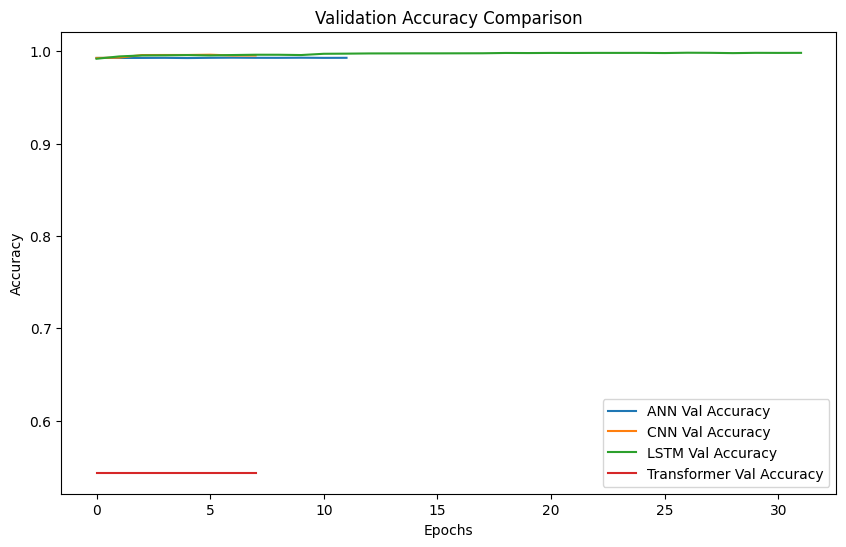

In [76]:

# Step 14: Visualize Training History Comparison
plt.figure(figsize=(10, 6))
plt.plot(history_ann.history['val_accuracy'], label='ANN Val Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='CNN Val Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='LSTM Val Accuracy')
plt.plot(history_transformer.history['val_accuracy'], label='Transformer Val Accuracy')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()
